<a href="https://colab.research.google.com/github/kgahadza/kg-data-science/blob/main/Optimizing_Index_Linked_Drought_Insurance_Using_Weather_Derivatives_Central_Illinois%2C_USA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import urllib.request
import json
import pandas as pd

# Central Illinois Counties and their approximate coordinates
counties = {
    'MCLEAN': {'lat': 40.4864, 'lon': -88.9937},
    'DE WITT': {'lat': 40.1748, 'lon': -88.9047},
    'LOGAN': {'lat': 40.1488, 'lon': -89.3648},
    'TAZEWELL': {'lat': 40.5125, 'lon': -89.5181},
    'WOODFORD': {'lat': 40.7893, 'lon': -89.2127}
}

weather_records = []

print("Starting API pull from NASA POWER...")
for county_name, info in counties.items():
    lat, lon = info['lat'], info['lon']
    # NASA POWER API for daily precipitation and max temperature
    url = f"https://power.larc.nasa.gov/api/temporal/daily/point?parameters=PRECTOTCORR,T2M_MAX&community=AG&longitude={lon}&latitude={lat}&start=19950701&end=20240731&format=JSON"

    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response:
            data = json.loads(response.read().decode())
            precip_data = data['properties']['parameter']['PRECTOTCORR']
            tmax_data = data['properties']['parameter']['T2M_MAX']

            # Aggregate for each July from 1995 to 2024
            for year in range(1995, 2025):
                july_precip = []
                july_edd = []

                for day in range(1, 32):
                    date_key = f"{year}07{day:02d}"
                    if date_key in precip_data:
                        p = precip_data[date_key]
                        t = tmax_data[date_key]

                        july_precip.append(p)
                        # EDD > 29 C threshold for corn heat stress
                        edd = max(0, t - 29.0)
                        july_edd.append(edd)

                weather_records.append({
                    'Year': year,
                    'County': county_name,
                    'July_Precip_mm': round(sum(july_precip), 2),
                    'July_EDD_C': round(sum(july_edd), 2)
                })
        print(f"Successfully fetched data for {county_name}")
    except Exception as e:
        print(f"Error for {county_name}: {e}")

df_weather = pd.DataFrame(weather_records)
df_weather.to_csv('Central_Illinois_July_Weather_1995_2024.csv', index=False)
print("Data saved to 'Central_Illinois_July_Weather_1995_2024.csv'")

Starting API pull from NASA POWER...
Successfully fetched data for MCLEAN
Successfully fetched data for DE WITT
Successfully fetched data for LOGAN
Successfully fetched data for TAZEWELL
Successfully fetched data for WOODFORD
Data saved to 'Central_Illinois_July_Weather_1995_2024.csv'


--- Correlation Matrix ---
                      Detrended_Yield_2024  July_Precip_mm  July_EDD_C
Detrended_Yield_2024              1.000000        0.459960   -0.620912
July_Precip_mm                    0.459960        1.000000   -0.419255
July_EDD_C                       -0.620912       -0.419255    1.000000

--- Strike Parameter Assessment ---
Average Yield during Drought (<=60.0mm): 199.60 bu/ac
Average Yield during Normal Years (>60.0mm): 230.06 bu/ac
Number of Payout Triggers (Historical): 18 out of 150 observations

Visualization saved as 'Index_Strike_Visualization.png'


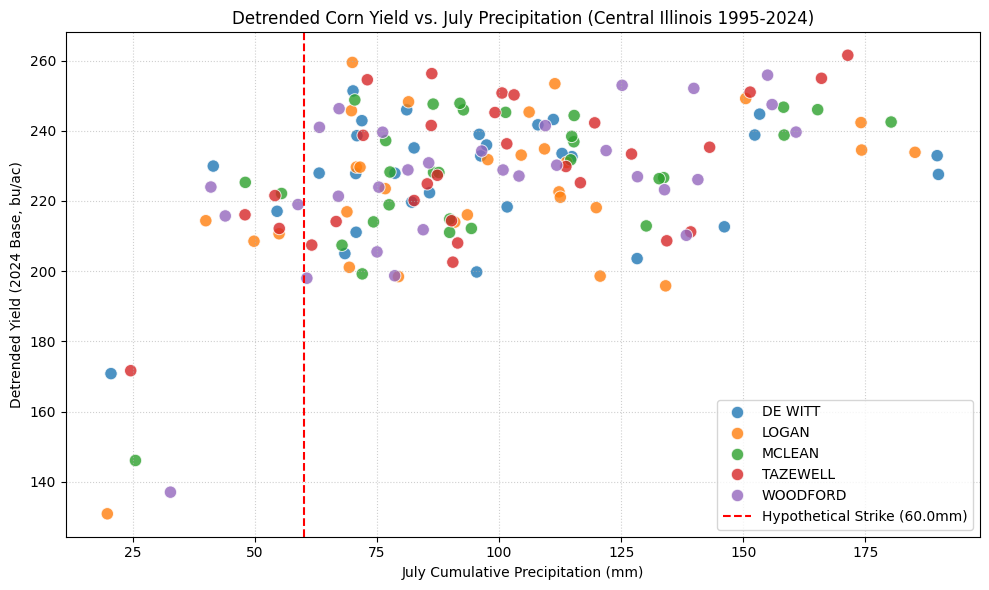

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-load and detrend the yield data to the 2024 technology baseline
df_yields = pd.read_csv('Central_Illinois_Corn_Yield_Panel_1995_2024.csv')
df_yields['Yield_Imputed'] = df_yields.groupby('County')['Corn_Yield_bu_per_acre'].transform(lambda group: group.interpolate(method='linear').bfill().ffill())

detrended_dfs = []
for county, group in df_yields.groupby('County'):
    group = group.sort_values('Year').copy()
    X = sm.add_constant(group['Year'])
    y = group['Yield_Imputed']
    model = sm.OLS(y, X).fit()
    slope = model.params['Year']
    # Detrend calculation
    group['Detrended_Yield_2024'] = group['Yield_Imputed'] + slope * (2024 - group['Year'])
    detrended_dfs.append(group)

df_yield_clean = pd.concat(detrended_dfs)

# 2. Load the newly extracted weather dataset
df_weather = pd.read_csv('Central_Illinois_July_Weather_1995_2024.csv')

# 3. Merge the datasets on Year and County
df_merged = pd.merge(df_yield_clean, df_weather, on=['Year', 'County'], how='inner')

# 4. Correlation Analysis for the Manuscript
print("--- Correlation Matrix ---")
corr_matrix = df_merged[['Detrended_Yield_2024', 'July_Precip_mm', 'July_EDD_C']].corr()
print(corr_matrix)

# 5. Strike Parameter Exploration (Historical Burn Analysis)
print("\n--- Strike Parameter Assessment ---")
# Let's test a hypothetical drought strike threshold of 60mm of July rainfall
strike_rainfall = 60.0

drought_years = df_merged[df_merged['July_Precip_mm'] <= strike_rainfall]
normal_years = df_merged[df_merged['July_Precip_mm'] > strike_rainfall]

print(f"Average Yield during Drought (<={strike_rainfall}mm): {drought_years['Detrended_Yield_2024'].mean():.2f} bu/ac")
print(f"Average Yield during Normal Years (>{strike_rainfall}mm): {normal_years['Detrended_Yield_2024'].mean():.2f} bu/ac")
print(f"Number of Payout Triggers (Historical): {len(drought_years)} out of {len(df_merged)} observations")

# 6. Visualization for the Paper
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x='July_Precip_mm', y='Detrended_Yield_2024', hue='County', s=80, alpha=0.8)
plt.title('Detrended Corn Yield vs. July Precipitation (Central Illinois 1995-2024)')
plt.xlabel('July Cumulative Precipitation (mm)')
plt.ylabel('Detrended Yield (2024 Base, bu/ac)')
plt.axvline(x=strike_rainfall, color='red', linestyle='--', label=f'Hypothetical Strike ({strike_rainfall}mm)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('Index_Strike_Visualization.png')
print("\nVisualization saved as 'Index_Strike_Visualization.png'")

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

try:
    df_yields = pd.read_csv('Central_Illinois_Corn_Yield_Panel_1995_2024.csv')
    df_weather = pd.read_csv('Central_Illinois_July_Weather_1995_2024.csv')

    # 1. Use 145 observed yields (Drop NA as requested)
    df_yields = df_yields.dropna(subset=['Corn_Yield_bu_per_acre']).copy()

    # 2. Detrending using Robust Regression (RLM)
    detrended_dfs = []
    for county, group in df_yields.groupby('County'):
        group = group.sort_values('Year').copy()
        X = sm.add_constant(group['Year'])
        y = group['Corn_Yield_bu_per_acre']
        model = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
        slope = model.params['Year']
        group['Detrended_Yield_2024'] = group['Corn_Yield_bu_per_acre'] + slope * (2024 - group['Year'])
        detrended_dfs.append(group)

    df_clean = pd.concat(detrended_dfs)
    df = pd.merge(df_clean, df_weather, on=['Year', 'County'], how='inner')

    # 3. Chronological Train/Test Split (Avoid Overfitting)
    # Train: 1995 - 2015 | Test: 2016 - 2024
    df_train = df[df['Year'] <= 2015].copy()
    df_test = df[df['Year'] > 2015].copy()

    # Define severe yield loss threshold (e.g., 15% below county normal)
    county_normals = df_train.groupby('County')['Detrended_Yield_2024'].mean()
    df_train['Normal_Yield'] = df_train['County'].map(county_normals)
    df_test['Normal_Yield'] = df_test['County'].map(county_normals)

    df_train['Loss_Event'] = df_train['Detrended_Yield_2024'] < (df_train['Normal_Yield'] * 0.85)
    df_test['Loss_Event'] = df_test['Detrended_Yield_2024'] < (df_test['Normal_Yield'] * 0.85)

    # 4. Optimize Benchmark Index (Precipitation Only)
    best_strike_rain = 0
    min_basis_risk = float('inf')

    for K in range(40, 120, 5):
        triggers = df_train['July_Precip_mm'] <= K
        fn = (df_train['Loss_Event'] & ~triggers).sum()
        fp = (~df_train['Loss_Event'] & triggers).sum()
        # Cost function prioritizes missing real disasters (FNs are worse than FPs)
        cost = (fn * 2) + fp
        if cost < min_basis_risk:
            min_basis_risk = cost
            best_strike_rain = K

    print(f"--- Benchmark (July Rainfall Only) Training Results ---")
    print(f"Optimized Strike: {best_strike_rain} mm")

    # Calculate Payouts and Premiums on Training Data
    df_train['Trigger'] = df_train['July_Precip_mm'] <= best_strike_rain
    drought_yield = df_train[df_train['Trigger']]['Detrended_Yield_2024'].mean()
    normal_yield = df_train[~df_train['Trigger']]['Detrended_Yield_2024'].mean()
    avg_deficit = best_strike_rain - df_train[df_train['Trigger']]['July_Precip_mm'].mean()

    rho = 4.50 # Assumed corn price per bushel
    tick_size = ((normal_yield - drought_yield) * rho) / avg_deficit
    df_train['Payout'] = np.maximum(0, best_strike_rain - df_train['July_Precip_mm']) * tick_size

    pi_hb = df_train['Payout'].mean()
    risk_loading = 0.2 * df_train['Payout'].std()
    commercial_premium = pi_hb + risk_loading

    print(f"Tick Size: ${tick_size:.2f} per mm")
    print(f"Historical Burn Premium: ${pi_hb:.2f}/acre")
    print(f"Commercial Premium: ${commercial_premium:.2f}/acre")

    # Validation (Out-of-Sample)
    df_test['Trigger'] = df_test['July_Precip_mm'] <= best_strike_rain
    tp = (df_test['Loss_Event'] & df_test['Trigger']).sum()
    fp = (~df_test['Loss_Event'] & df_test['Trigger']).sum()
    fn = (df_test['Loss_Event'] & ~df_test['Trigger']).sum()
    tn = (~df_test['Loss_Event'] & ~df_test['Trigger']).sum()

    print(f"\n--- Benchmark Validation (2016-2024) ---")
    print(f"True Positives (Payout hit Loss): {tp}")
    print(f"False Positives (Overcompensation): {fp}")
    print(f"False Negatives (Missed Loss): {fn}")

    # 5. Optimize Proposed Index (Combined Rain + Extreme Heat)
    best_cost = float('inf')
    best_K_R = 0
    best_K_EDD = 0

    for k_r in range(40, 100, 5):
        for k_e in range(10, 60, 5):
            triggers = (df_train['July_Precip_mm'] <= k_r) | (df_train['July_EDD_C'] >= k_e)
            fn_comb = (df_train['Loss_Event'] & ~triggers).sum()
            fp_comb = (~df_train['Loss_Event'] & triggers).sum()
            cost = (fn_comb * 2) + fp_comb
            if cost < best_cost:
                best_cost = cost
                best_K_R = k_r
                best_K_EDD = k_e

    print(f"\n--- Proposed Index (Rain + Heat) Training Results ---")
    print(f"Optimized Rainfall Strike: {best_K_R} mm")
    print(f"Optimized Heat Strike: {best_K_EDD} EDD")

    # Validation
    df_test['Trigger_Comb'] = (df_test['July_Precip_mm'] <= best_K_R) | (df_test['July_EDD_C'] >= best_K_EDD)
    tp_c = (df_test['Loss_Event'] & df_test['Trigger_Comb']).sum()
    fp_c = (~df_test['Loss_Event'] & df_test['Trigger_Comb']).sum()
    fn_c = (df_test['Loss_Event'] & ~df_test['Trigger_Comb']).sum()

    print(f"\n--- Proposed Validation (2016-2024) ---")
    print(f"True Positives (Payout hit Loss): {tp_c}")
    print(f"False Positives (Overcompensation): {fp_c}")
    print(f"False Negatives (Missed Loss): {fn_c}")

except Exception as e:
    print(f"Error: {e}")

--- Benchmark (July Rainfall Only) Training Results ---
Optimized Strike: 40 mm
Tick Size: $23.43 per mm
Historical Burn Premium: $17.37/acre
Commercial Premium: $33.60/acre

--- Benchmark Validation (2016-2024) ---
True Positives (Payout hit Loss): 0
False Positives (Overcompensation): 0
False Negatives (Missed Loss): 0

--- Proposed Index (Rain + Heat) Training Results ---
Optimized Rainfall Strike: 40 mm
Optimized Heat Strike: 55 EDD

--- Proposed Validation (2016-2024) ---
True Positives (Payout hit Loss): 0
False Positives (Overcompensation): 6
False Negatives (Missed Loss): 0
